In [1]:
! pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import itertools
import pathlib
import glob
import shutil
from zipfile import ZipFile
from IPython.display import FileLink
import os
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

local_zip = '/content/drive/MyDrive/Colab Notebooks/KlasifikasiPatahTulang/klasifikasi-patah-tulang.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')

In [ ]:
zip_ref.extractall('/content/drive/MyDrive/DATA MINING')
zip_ref.close()

In [ ]:
path="/content/drive/MyDrive/DATA MINING/klasifikasi-patah-tulang/train"

### Data Information

In [ ]:
path="/content/drive/MyDrive/DATA MINING/klasifikasi-patah-tulang/train"

class_names = sorted(os.listdir(path))
n_classes = len(class_names)

class_dis = [len(os.listdir(path + f"/{name}")) for name in class_names]
print(f"Class Distribution : \n{class_dis}")

Class Distribution : 
[876, 423, 422, 630, 540, 493, 536]


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1317/4137305236.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=class_names, x=class_dis, palette=colors, orient='h')


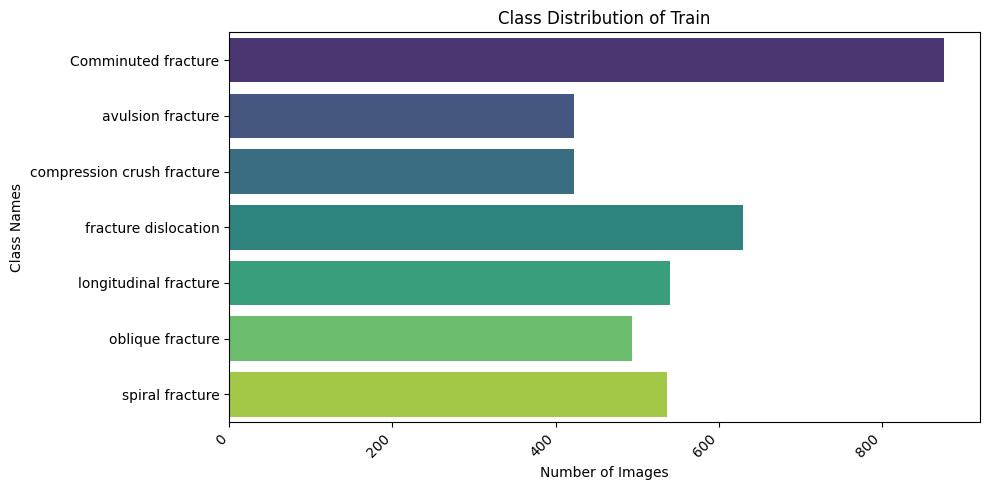

In [ ]:
colors = sns.color_palette('viridis', n_classes)
plt.figure(figsize=(10, 5))
sns.barplot(y=class_names, x=class_dis, palette=colors, orient='h')

# Add labels and title
plt.xlabel('Number of Images')
plt.ylabel('Class Names')
plt.title('Class Distribution of Train')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [ ]:
path="/content/drive/MyDrive/DATA MINING/klasifikasi-patah-tulang/valid"

class_names = sorted(os.listdir(path))
n_classes = len(class_names)

class_dis = [len(os.listdir(path + f"/{name}")) for name in class_names]
print(f"Class Distribution : \n{class_dis}")

Class Distribution : 
[623, 300, 212, 355, 300, 257, 388]


In [ ]:
path="/content/drive/MyDrive/DATA MINING/klasifikasi-patah-tulang/train"

class_names = sorted(os.listdir(path))
n_classes = len(class_names)

class_dis = [len(os.listdir(path + f"/{name}")) for name in class_names]
print(f"Class Distribution : \n{class_dis}")

Class Distribution : 
[876, 423, 422, 630, 540, 493, 536]


/tmp/ipykernel_1317/4137305236.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=class_names, x=class_dis, palette=colors, orient='h')


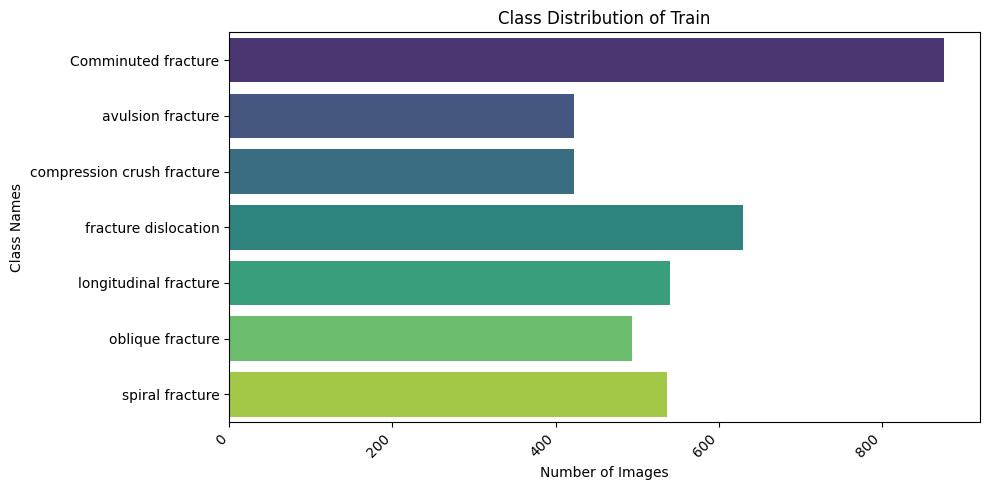

In [ ]:
colors = sns.color_palette('viridis', n_classes)
plt.figure(figsize=(10, 5))
sns.barplot(y=class_names, x=class_dis, palette=colors, orient='h')

# Add labels and title
plt.xlabel('Number of Images')
plt.ylabel('Class Names')
plt.title('Class Distribution of Train')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

### Data Generator

In [ ]:
path_train ="/content/drive/MyDrive/DATA MINING/klasifikasi-patah-tulang/train"
path_validation="/content/drive/MyDrive/DATA MINING/klasifikasi-patah-tulang/valid"

train_datagen = ImageDataGenerator(rescale = 1.0/255.,
                                   zoom_range=0.2,
                                   rotation_range=32,
                                   brightness_range=[0.2,1.0],
                                   horizontal_flip=True)

validation_datagen = ImageDataGenerator(rescale=1.0/255.)

train_generator = train_datagen.flow_from_directory(path_train,
                                                    target_size = (224, 224),
                                                    batch_size = 32,
                                                    class_mode='categorical',
                                                    shuffle=True)

validation_generator = validation_datagen.flow_from_directory(path_validation,
                                                              target_size = (224, 224),
                                                              batch_size = 32,
                                                              class_mode='categorical',
                                                              shuffle=False)

Found 3844 images belonging to 7 classes.
Found 2388 images belonging to 7 classes.


### Function Utility

In [ ]:
def show_image_per_class(directory, classes):
    num_classes = len(classes)
    num_rows = 7
    num_cols = 7

    plt.figure(figsize=(15, num_rows * 3))
    for i, class_name in enumerate(classes[:num_rows * num_cols]):
        class_dir = os.path.join(directory, class_name)
        img_file = random.choice(os.listdir(class_dir))
        img_path = os.path.join(class_dir, img_file)
        img = plt.imread(img_path)
        plt.subplot(num_rows, num_cols, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')

    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    plt.show()


In [ ]:
def Show_Images(target_gen):
    batch_images, batch_labels = next(target_gen)

    class_labels = list(target_gen.class_indices.keys())

    plt.figure(figsize=(20, 20))
    for n, i in enumerate(list(np.random.randint(0, len(batch_images), 16))):
        plt.subplot(4, 4, n + 1)
        plt.imshow(batch_images[i])
        plt.title(class_labels[np.argmax(batch_labels[i])])
        plt.axis('off')
    plt.show()


### Show Images

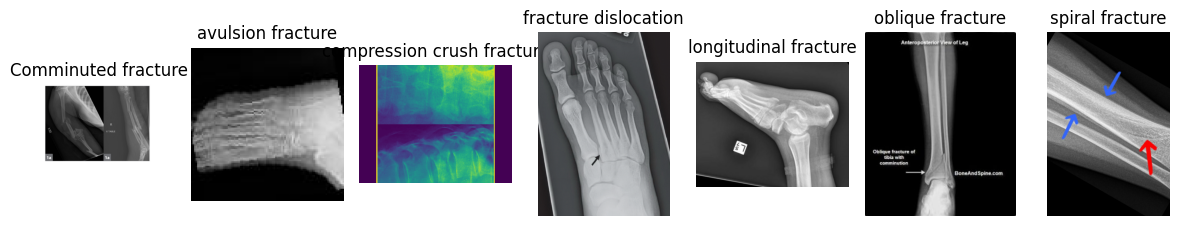

In [ ]:
show_image_per_class(path_train, class_names)

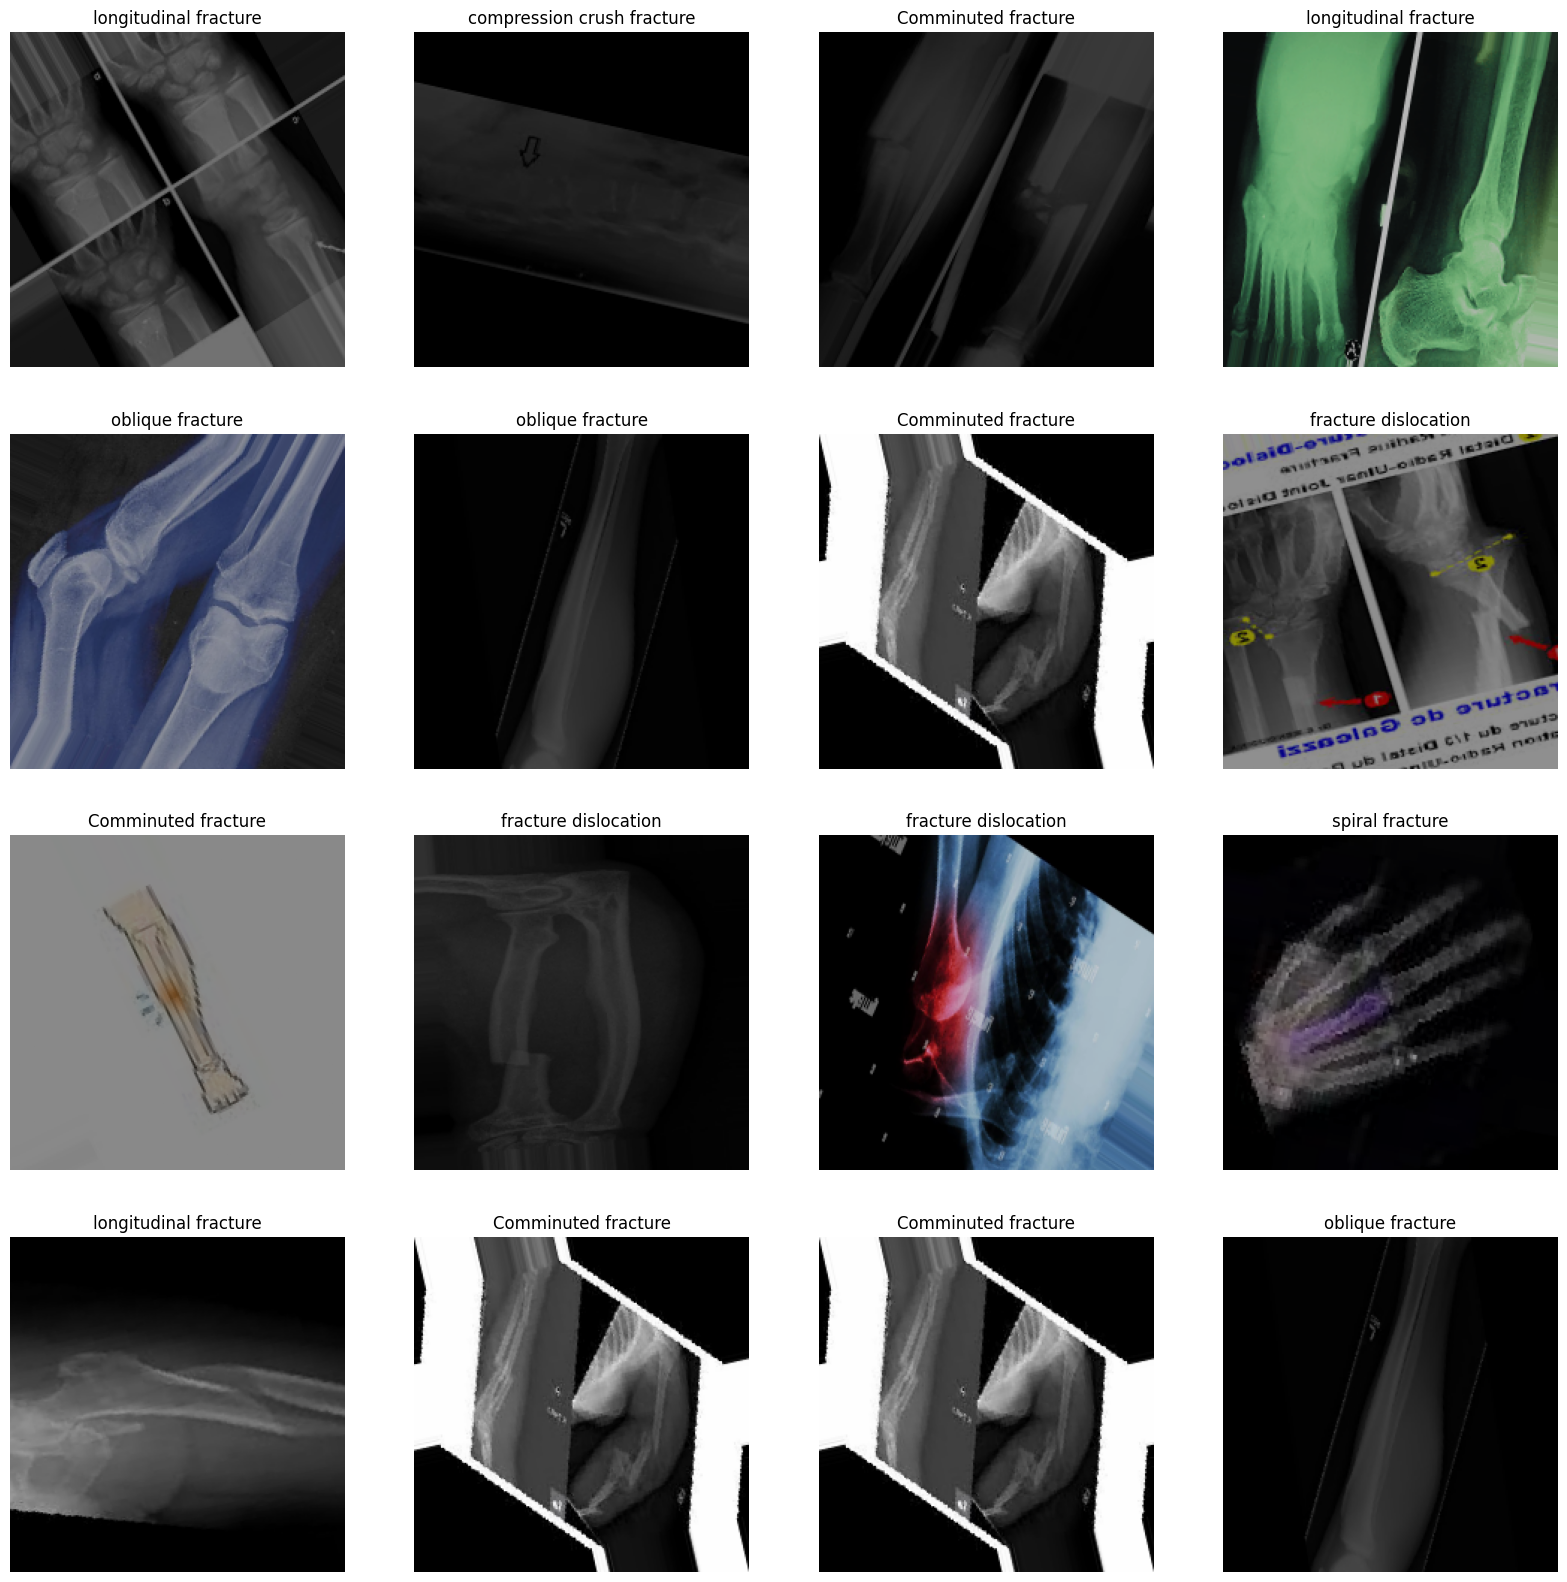

In [ ]:
Show_Images(train_generator)

### Model Training

In [ ]:
input_shape = (224, 224, 3)
pre_trained_model = tf.keras.applications.MobileNetV2(weights="imagenet",
                                include_top=False,
                                input_tensor=tf.keras.layers.Input(shape=input_shape))

for layer in pre_trained_model.layers:
    layer.trainable = True


/tmp/ipykernel_1317/355345359.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  pre_trained_model = tf.keras.applications.MobileNetV2(weights="imagenet",


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model = tf.keras.models.Sequential()

model.add(pre_trained_model)

model.add(tf.keras.layers.Flatten(name="flatten"))

model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0001)))
model.add(tf.keras.layers.BatchNormalization())

model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.Dense(7, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,028,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,287,687 (39.24 MB)

 Trainable params: 10,253,319 (39.11 MB)

 Non-trainable params: 34,368 (134.25 KB)

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(0.0001),
              metrics=['accuracy'])

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                              patience=3,
                              factor=0.5,
                              min_lr=1e-6)

In [ ]:
model_name = "model_checkpoint2.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(model_name,
                             monitor="val_accuracy",
                             mode="max",mais
                             save_best_only=True,
                             verbose=1)

In [ ]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')>0.95 and logs.get('val_accuracy') > 0.95 ):
      print("\nReached 95% both accuracy so cancelling training!")
      self.model.stop_training = True

callbacks = myCallback()

In [ ]:
early_stopping = EarlyStopping(monitor='val_accuracy',
                               patience=5,
                               restore_best_weights=True)

In [ ]:
history = model.fit(
      train_generator,
      epochs=100,
      verbose=1,
      validation_data = validation_generator,
      callbacks=[checkpoint, reduce_lr, callbacks, early_stopping],
      )

Epoch 1/100
  7/121 ━━━━━━━━━━━━━━━━━━━━ 59s 526ms/step - accuracy: 0.1238 - loss: 3.2325

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2426 - loss: 2.7378
Epoch 1: val_accuracy improved from None to 0.41248, saving model to model_checkpoint2.keras

Epoch 1: finished saving model to model_checkpoint2.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.3145 - loss: 2.4349 - val_accuracy: 0.4125 - val_loss: 1.6872 - learning_rate: 1.0000e-04
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.4282 - loss: 1.8612
Epoch 2: val_accuracy improved from 0.41248 to 0.49749, saving model to model_checkpoint2.keras

Epoch 2: finished saving model to model_checkpoint2.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 111s 915ms/step - accuracy: 0.4501 - loss: 1.7676 - val_accuracy: 0.4975 - val_loss: 1.5150 - learning_rate: 1.0000e-04
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.5143 - loss: 1.5316
Epoch 3: val_accuracy did not improve from 0.49749
121/121 ━━━━━━━━━━━━━━━━━━━━ 109s 897ms/step - accuracy: 0.5180 - loss: 1.5104 - val_accuracy: 

### Training and Validation History

In [ ]:
training_history = history.history
training_df = pd.DataFrame(training_history)
print(training_df.tail())

    accuracy      loss  val_accuracy  val_loss  learning_rate
39  0.897503  0.299105      0.930905  0.219791       0.000025
40  0.899844  0.297333      0.932580  0.210712       0.000025
41  0.908689  0.287635      0.930486  0.212112       0.000012
42  0.901925  0.295479      0.932161  0.210588       0.000012
43  0.902966  0.283736      0.931742  0.211967       0.000012


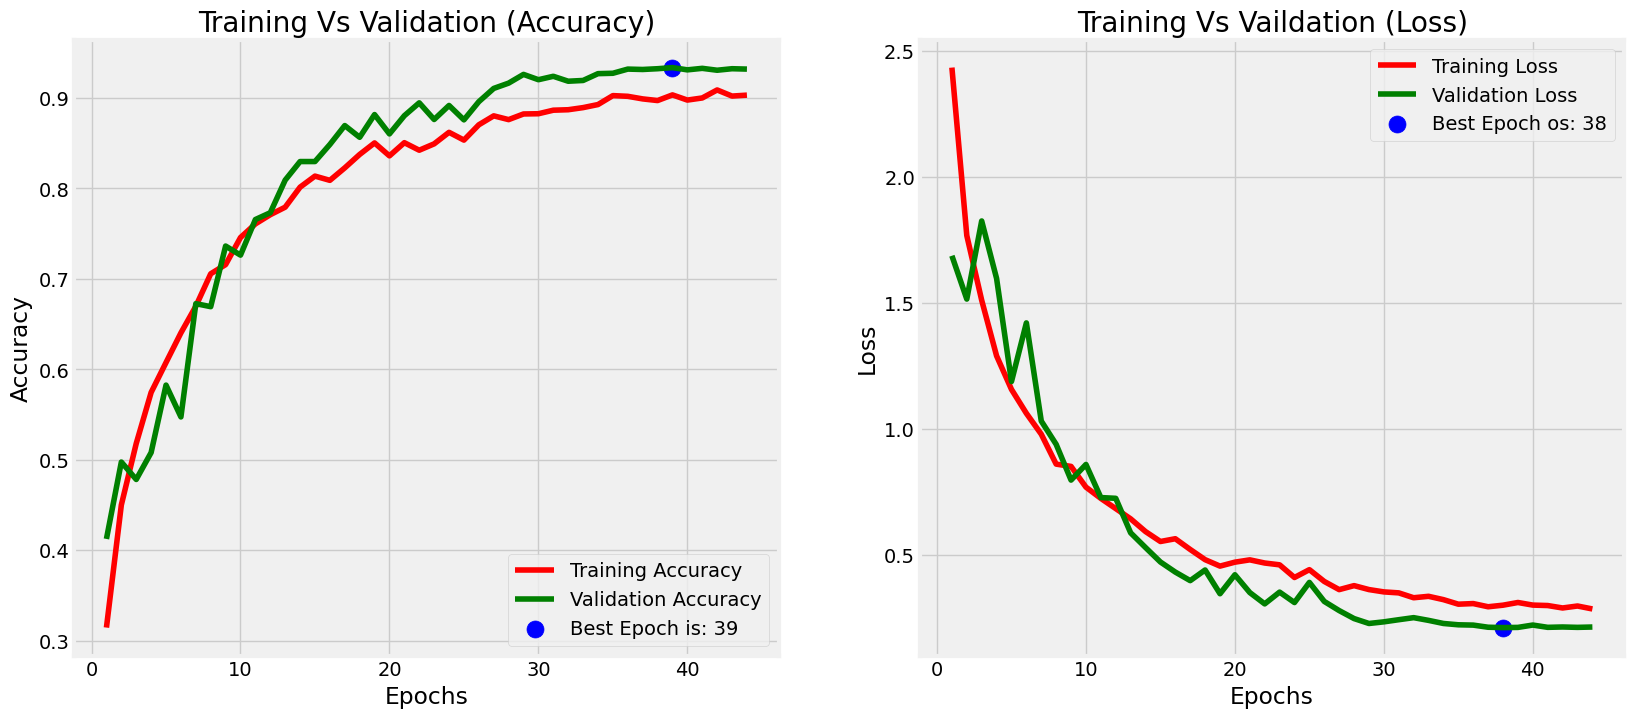

In [ ]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
index_acc= np.argmax(val_acc)

val_lowest= val_loss[index_loss]
val_highest = val_acc[index_acc]

epochs= [i+1 for i in range(len(train_acc))]
acc_label = f"Best Epoch is: {str(index_acc +1)}"
loss_label = f"Best Epoch os: {str(index_loss +1)}"

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(epochs , train_acc , 'r' , label= "Training Accuracy")
plt.plot(epochs , val_acc , 'g' , label= "Validation Accuracy")
plt.scatter(index_acc +1 ,val_highest , s = 150 , c= 'blue', label= acc_label)
plt.title('Training Vs Validation (Accuracy)')
plt.xlabel("Epochs")
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs , train_loss , 'r' , label= "Training Loss")
plt.plot(epochs , val_loss , 'g' , label= "Validation Loss")
plt.scatter(index_loss +1 , val_lowest , s= 150 , c = 'blue' , label= loss_label)
plt.title("Training Vs Vaildation (Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout
plt.show();

In [ ]:
# Save the model in .h5 format
model.save('bone_cracking_classification_model.h5')


In [ ]:
model.save('bone_cracking_classification_model.keras')

In [ ]:
import os

# Tentukan path ke direktori Downloads
save_dir = os.path.expanduser("~/Downloads")
os.makedirs(save_dir, exist_ok=True)

# Tentukan path lengkap untuk file model
model_path = os.path.join(save_dir, "bone_cracking_classification_model.h5")

# Simpan model ke dalam file .h5 di direktori Downloads
model.save(model_path)

print(f"Model has been saved to {model_path}")

Model has been saved to /root/Downloads/bone_cracking_classification_model.h5
